# Analyse des runs agent — Immo
Visualisation des performances et de la stabilité de l'agent sur les runs d'évaluation.

In [15]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import psycopg2
import os

from pathlib import Path
from dotenv import load_dotenv

load_dotenv()
conn = psycopg2.connect(os.getenv("DATABASE_URL"))

# On télécharge tout l'historique des outils utilisés
df_tools = pd.read_sql("SELECT * FROM run_operations", conn)

# On filtre par exemple sur une opération où l'agent s'est trompé (votre False) :
operation_ratee = "op_901"
outils_utilises = df_tools[df_tools["operation_id"] == operation_ratee]

print(f"Outils déclenchés par l'agent pour {operation_ratee}:")
outils_utilises[["tool_name", "tool_args", "resultat"]]


OUTPUTS_PATH = Path("outputs")
GROUND_TRUTH_PATH = Path("data/ground_truth.json")

with open(GROUND_TRUTH_PATH, encoding="utf-8") as f:
    gt = {c["operation_id"]: c for c in json.load(f)}

print(f"{len(list(OUTPUTS_PATH.glob('*.json')))} fichiers outputs trouvés")
print(f"{len(gt)} opérations dans la ground truth")

C:\Users\natha\AppData\Local\Temp\ipykernel_7004\2041995435.py:16: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_tools = pd.read_sql("SELECT * FROM run_operations", conn)


Outils déclenchés par l'agent pour op_901:
6 fichiers outputs trouvés
9 opérations dans la ground truth


## 1. Construction du dataset sur les 3 runs (run_eval.py - defaut 3)

In [16]:
# 1. On ouvre l'historique des métriques 
with open("results/metrics_history.json", "r", encoding="utf-8") as f:
    historique = json.load(f)

# 2. On crée une liste simple pour stocker nos lignes
lignes_tableau = []

# Pour chaque Run, on regarde la liste de ses résultats par opération
for run in historique:
    for op in run["resultats_par_operation"]:
        
        # On recopie  les clés déjà existantes dans le JSON 
        lignes_tableau.append({
            "run_id":     run["run_id"],
            "company_id": run["company_id"],
            "operation":  op["operation_id"],
            "difficulte": op["difficulte"],
            "attendu":    op["decision_attendue"],
            "obtenu":     op["decision_agent"],
            "confiance":  op["confiance"],
            "correct":    op["correct"]
        })

# 3. On affiche notre beau tableau Pandas
df = pd.DataFrame(lignes_tableau)

print(f"Dataset prêt : {len(df)} lignes analysées.")
df.head(27)


Dataset prêt : 54 lignes analysées.


,run_id,company_id,operation,difficulte,attendu,obtenu,confiance,correct
0,20260413_1924,company_1,op_891,moyen,split_operation,split_operation,0.95,True
1,20260413_1924,company_1,op_892,facile,charge_confirmed,charge_confirmed,0.95,True
2,20260413_1924,company_1,op_893,facile,reclassification,reclassification,0.97,True
3,20260413_1924,company_1,op_894,difficile,split_operation,split_operation,0.92,True
4,20260413_1924,company_1,op_895,facile,charge_confirmed,charge_confirmed,0.99,True
5,20260413_1924,company_1,op_896,difficile,human_review,human_review,0.95,True
6,20260413_1927,company_1,op_891,moyen,split_operation,split_operation,0.95,True
7,20260413_1927,company_1,op_892,facile,charge_confirmed,charge_confirmed,0.92,True
8,20260413_1927,company_1,op_893,facile,reclassification,reclassification,0.97,True
9,20260413_1927,company_1,op_894,difficile,split_operation,split_operation,0.92,True


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   run_id        27 non-null     str    
 1   company_id    27 non-null     str    
 2   prompt        27 non-null     str    
 3   model         27 non-null     str    
 4   operation_id  27 non-null     str    
 5   difficulty    27 non-null     str    
 6   attendu       27 non-null     str    
 7   obtenu        27 non-null     str    
 8   confidence    27 non-null     float64
 9   correct       27 non-null     bool   
dtypes: bool(1), float64(1), str(8)
memory usage: 2.1 KB


## 2 - Comparatif performance de l'agent sur grap en bar

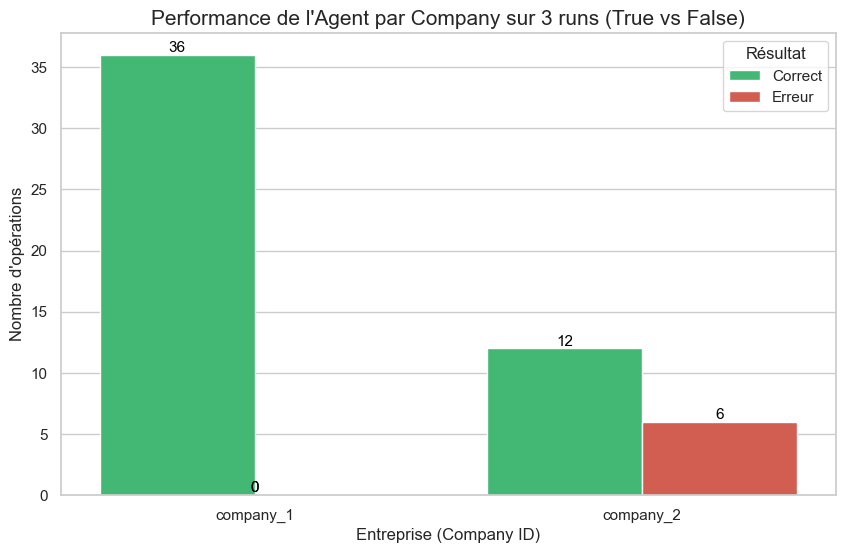

In [32]:
# 2. On s'assure que 'correct' est bien un texte ou un format lisible pour le graph
df['statut_decision'] = df['correct'].map({True: 'Correct', False: 'Erreur'})

# 3. Configuration du style
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 4. Création du graphique en barres
ax = sns.countplot(
    data=df, 
    x='company_id', 
    hue='statut_decision', 
    palette={'Correct': '#2ecc71', 'Erreur': '#e74c3c'}
)

# 5. Personnalisation
plt.title('Performance de l\'Agent par Company sur 3 runs (True vs False)', fontsize=15)
plt.xlabel('Entreprise (Company ID)', fontsize=12)
plt.ylabel('Nombre d\'opérations', fontsize=12)
plt.legend(title='Résultat')

# Ajout des étiquettes de score sur les barres
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', fontsize=11, color='black', xytext=(0, 5),
                textcoords='offset points')

plt.show()

## 3 - Identification des erreurs

In [11]:
# On filtre pour ne garder que les erreurs
erreurs_df = df[df['correct'] == False]

# On affiche les colonnes clés pour l'analyse
print(f"Nombre total d'erreurs : {len(erreurs_df)}")
erreurs_df[['operation_id', 'difficulty', 'attendu', 'obtenu', 'confidence']]

Nombre total d'erreurs : 3


,operation_id,difficulty,attendu,obtenu,confidence
18,op_901,moyen,human_review,request_client_info,0.62
21,op_901,moyen,human_review,request_client_info,0.92
24,op_901,moyen,human_review,request_client_info,0.40


### j'ai fais une erreur dans le ground_truth.json : op_901 doit être "request_client_info" l'agent a bien identifié la bonne réponse. Je laisse comme cela pour voir un cas avec erreur.

## 4 - Analyse recall agent

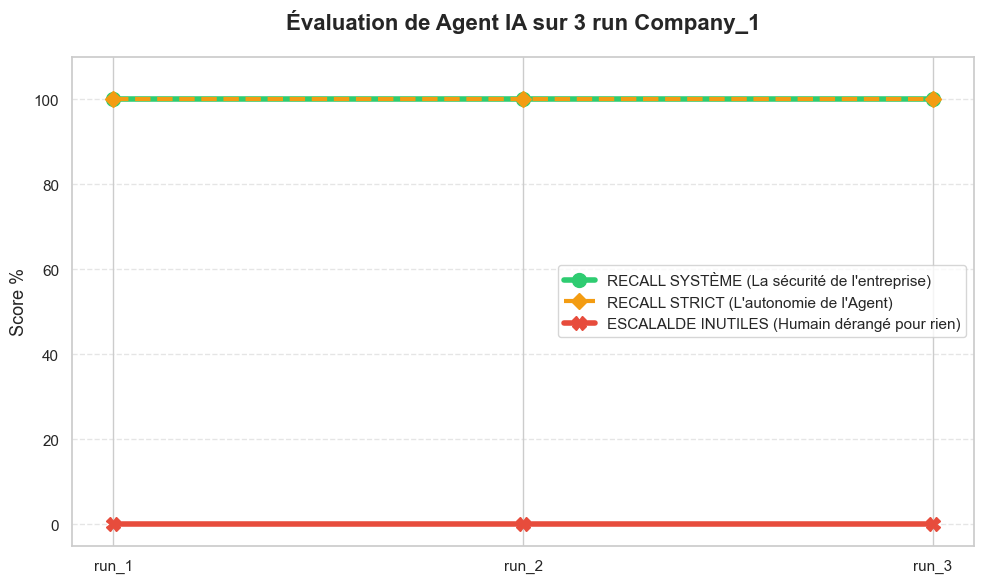

In [33]:
# On récupère les runs de la company_1 (Façon "Junior" claire)
runs_company_1 = []
for run in historique:
    if run["company_id"] == "company_1":
        runs_company_1.append(run)

# On garde uniquement les 3 derniers
trois_derniers_runs = runs_company_1[-3:]
noms_des_runs = ["run_1", "run_2", "run_3"] 

# 3. On extrait nos trois scores ! (Avec des boucles simples)
scores_systeme = []
scores_strict = []
score_escalades_inutiles = []

for run in trois_derniers_runs:
    scores_systeme.append(run["recall_system"] * 100)           # Fois 100 pour %
    scores_strict.append(run["recall_strict"] * 100)
    score_escalades_inutiles.append(run["escalade_inutile_rate"] * 100)


# 4. Affichage du graphique 
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(noms_des_runs, scores_systeme, 
        label="RECALL SYSTÈME (La sécurité de l'entreprise)", 
        color="#2ecc71", marker="o", linewidth=4, markersize=10)

ax.plot(noms_des_runs, scores_strict, 
        label="RECALL STRICT (L'autonomie de l'Agent)", 
        color="#f39c12", marker="D", linewidth=3, markersize=8, linestyle="dashed")

ax.plot(noms_des_runs, score_escalades_inutiles, 
        label="ESCALALDE INUTILES (Humain dérangé pour rien)", 
        color="#e74c3c", marker="X", linewidth=4, markersize=10)

# Cosmétique de la fenêtre
ax.set_title("Évaluation de Agent IA sur 3 run Company_1", fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel("Score %", fontsize=13)
ax.set_ylim(-5, 110)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
ax.legend(fontsize=11, loc='center right')

plt.tight_layout()
plt.show()


 Pourquoi utiliser deux Recalls différents ?

1. Recall SYSTEME = Le Bouclier (Sécurité)

La question : "Une erreur a-t-elle échappé à la fois à l'IA et au comptable humain ?"
L'enjeu : Rassurer l'entreprise et la direction. Tant qu'il est à 100%, la comptabilité est sous cloche et le système entier est sûr.

2. Recall STRICT = Le ROI (Gain de temps)

La question : "Combien de dossiers l'IA a-t-elle réussi à ranger de A à Z en totale autonomie ?"
L'enjeu : Rentabiliser l'IA. Si elle alerte un humain au moindre doute (Recall Strict faible), le cabinet comptable ne gagne aucun temps et l'IA est inutile.

Conclusion Métier : Un agent paranoïaque qui n'ose rien faire récoltera toujours un Recall Système de 100%. Le véritable accomplissement tech de ce projet est de faire grimper le Recall Strict (réussite autonome) sans jamais abîmer le Recall Système (sécurité totale).

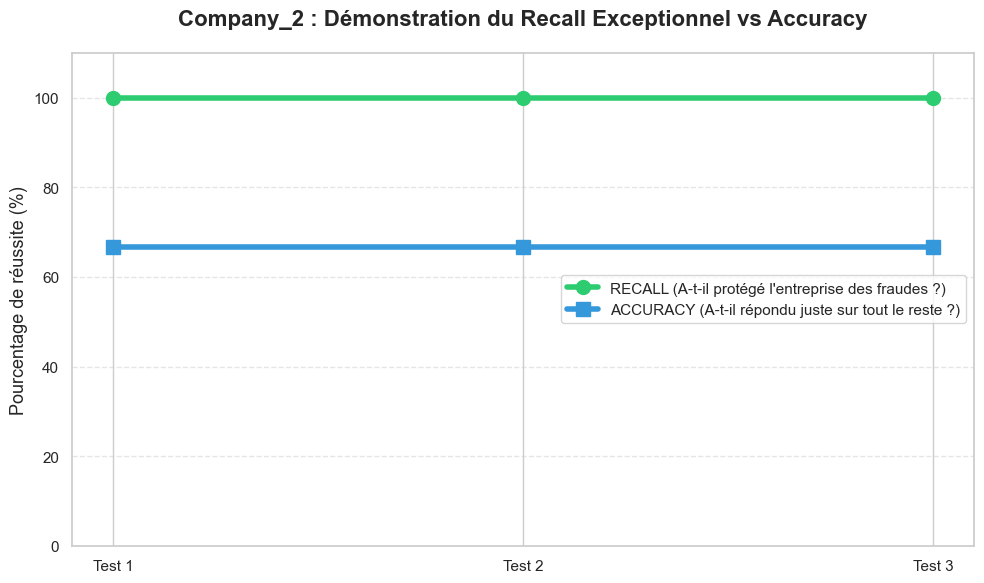

In [30]:
import json
import matplotlib.pyplot as plt

# 1. Chargement
with open("results/metrics_history.json", "r", encoding="utf-8") as f:
    historique = json.load(f)

# 2. Cette fois on filtre sur vos essais de la "company_2"
runs_company = []
for run in historique:
    if run["company_id"] == "company_2":
        runs_company.append(run)

trois_derniers_runs = runs_company[-3:]
noms_des_tests = ["Test 1", "Test 2", "Test 3"] 

# 3. On extrait les deux amis : Accuracy et Recall
scores_globaux = []
scores_systeme = []

for run in trois_derniers_runs:
    # On multiplie par 100 pour que le 0.667 devienne 66.7% sur le schéma
    scores_globaux.append(run["score_global"] * 100) 
    scores_systeme.append(run["recall_system"] * 100)

# 4. Le Dessin de comparaison ultime
fig, ax = plt.subplots(figsize=(10, 6))

# Courbe Verte (Recall)
ax.plot(noms_des_tests, scores_systeme, 
        label="RECALL (A-t-il protégé l'entreprise des fraudes ?)", 
        color="#2ecc71", marker="o", linewidth=4, markersize=10)

# Courbe Bleue (Accuracy)
ax.plot(noms_des_tests, scores_globaux, 
        label="ACCURACY (A-t-il répondu juste sur tout le reste ?)", 
        color="#3498db", marker="s", linewidth=4, markersize=10)

ax.set_title("Company_2 : Démonstration du Recall Exceptionnel vs Accuracy", fontsize=16, fontweight='bold', pad=20)
ax.set_ylabel("Pourcentage de réussite (%)", fontsize=13)
ax.set_ylim(0, 110)
ax.grid(True, axis='y', linestyle='--', alpha=0.5)
ax.legend(fontsize=11, loc='center right')

plt.tight_layout()
plt.show()


### Le recall system est a 100 et l'acuracy à 0.67. L'agent a bien identifié toutes les factures d'immobilisations, mais c'est trompé sur une une demande "human review" donc 1 erreur / 3 = 0.67. L'acuracy s'ets le nombre de fois ou l'agent à pris la même décision que le comptable

## 5 - Tableau récap des scores c_1 & c_2 sur les 3 runs

In [ ]:

# On le transforme en Tableau Pandas en ne gardant que les colonnes qui nous intéressent
df_scores = pd.DataFrame(historique)[["run_id", "company_id", "score_global", "recall_strict", "recall_system", "escalade_inutile_rate"]]

# 3. Et voilà le travail !
df_scores


,run_id,company_id,score_global,recall_strict,recall_system,escalade_inutile_rate
0,20260413_1924,company_1,1.000,1.0,1.0,0.0
1,20260413_1927,company_1,1.000,1.0,1.0,0.0
2,20260413_1930,company_1,1.000,1.0,1.0,0.0
3,20260413_1924,company_1,1.000,1.0,1.0,0.0
4,20260413_1927,company_1,1.000,1.0,1.0,0.0
5,20260413_1930,company_1,1.000,1.0,1.0,0.0
6,20260413_1932,company_2,0.667,1.0,1.0,0.0
7,20260413_1934,company_2,0.667,1.0,1.0,0.0
8,20260413_1936,company_2,0.667,1.0,1.0,0.0
9,20260413_1932,company_2,0.667,1.0,1.0,0.0
